In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Set Google Drive paths

In [2]:
import os

project_path = '/content/drive/MyDrive/MSIL Project/ADL'

os.listdir(project_path)

['1753252736_train_and_deploy_a_cnn_model_using_tensorflow_serving_problem_statement.pdf',
 'Datasets.zip',
 'retinopathy_data',
 'Train and Deploy a CNN Model Using TensorFlow Serving.ipynb']

Find the exact file location

In [3]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "Datasets.zip" in files or "Train and Deploy a CNN Model Using TensorFlow Serving.ipynb" in files:
        print("\nFOLDER:", root)

        if "Datasets.zip" in files:
            print("DATASET:", os.path.join(root, "Datasets.zip"))

        if "Train and Deploy a CNN Model Using TensorFlow Serving.ipynb" in files:
            print("NOTEBOOK:", os.path.join(
                root,
                "Train and Deploy a CNN Model Using TensorFlow Serving.ipynb"
            ))


FOLDER: /content/drive/MyDrive/MSIL Project/Capstone
DATASET: /content/drive/MyDrive/MSIL Project/Capstone/Datasets.zip

FOLDER: /content/drive/MyDrive/MSIL Project/NLP
DATASET: /content/drive/MyDrive/MSIL Project/NLP/Datasets.zip

FOLDER: /content/drive/MyDrive/MSIL Project/ADL
DATASET: /content/drive/MyDrive/MSIL Project/ADL/Datasets.zip
NOTEBOOK: /content/drive/MyDrive/MSIL Project/ADL/Train and Deploy a CNN Model Using TensorFlow Serving.ipynb


Define the ADL project paths

In [4]:
import os

PROJECT_PATH = "/content/drive/MyDrive/MSIL Project/ADL"

DATASET_ZIP = os.path.join(PROJECT_PATH, "Datasets.zip")
PROJECT_NOTEBOOK = os.path.join(
    PROJECT_PATH,
    "Train and Deploy a CNN Model Using TensorFlow Serving.ipynb"
)

print("Dataset ZIP exists:", os.path.exists(DATASET_ZIP))
print("Notebook exists:", os.path.exists(PROJECT_NOTEBOOK))
print("Dataset path:", DATASET_ZIP)

Dataset ZIP exists: True
Notebook exists: True
Dataset path: /content/drive/MyDrive/MSIL Project/ADL/Datasets.zip


Inspect the ZIP structure

In [5]:
import zipfile
import os

with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    file_list = zip_ref.namelist()

print("Total files/folders in ZIP:", len(file_list))

print("\nFirst 30 items:")
for item in file_list[:30]:
    print(item)

Total files/folders in ZIP: 41

First 30 items:
Assisted_Practices_datasets/
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Detecting_Lines/
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Detecting_Lines/CurvedRoad.jpg
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Detecting_Lines/Highway.jpg
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Detecting_Lines/line and circle.png.png
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Detecting_Lines/NightRoad.jpg
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Drawing_Contour/
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Drawing_Contour/horse_new.png
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Drawing_Rectangles/
Assisted_Practices_datasets/Lesson_02_Image_Formation_and_Processing/Drawing_Rectangles/

Check the extracted files

In [6]:
import os
import zipfile

# Create a working folder in Google Drive
DATA_DIR = os.path.join(PROJECT_PATH, "retinopathy_data")
os.makedirs(DATA_DIR, exist_ok=True)

# Extract only CEP_01 files from the main ZIP
with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    for file_name in zip_ref.namelist():
        if file_name.startswith("Course_end_project_datasets/CEP_01/"):
            zip_ref.extract(file_name, DATA_DIR)

print("Required project files extracted.")

Required project files extracted.


Check the extracted files

In [7]:
import os

EXTRACTED_CEP_PATH = os.path.join(
    DATA_DIR,
    "Course_end_project_datasets",
    "CEP_01"
)

print("CEP_01 folder:", EXTRACTED_CEP_PATH)

print("\nFiles inside CEP_01:")
for item in os.listdir(EXTRACTED_CEP_PATH):
    print("-", item)

SAMPLE_ZIP = os.path.join(EXTRACTED_CEP_PATH, "Sample.zip")
LABELS_CSV = os.path.join(EXTRACTED_CEP_PATH, "trainLabels.csv")

print("\nSample.zip exists:", os.path.exists(SAMPLE_ZIP))
print("trainLabels.csv exists:", os.path.exists(LABELS_CSV))

CEP_01 folder: /content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/Course_end_project_datasets/CEP_01

Files inside CEP_01:
- Sample.zip
- trainLabels.csv

Sample.zip exists: True
trainLabels.csv exists: True


Inspect the images inside Sample.zip

In [8]:
import zipfile

with zipfile.ZipFile(SAMPLE_ZIP, "r") as zip_ref:
    image_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

print("Total images inside Sample.zip:", len(image_files))

print("\nFirst 20 image files:")
for file in image_files[:20]:
    print(file)

Total images inside Sample.zip: 10

First 20 image files:
sample/10_left.jpeg
sample/10_right.jpeg
sample/13_left.jpeg
sample/13_right.jpeg
sample/15_left.jpeg
sample/15_right.jpeg
sample/16_left.jpeg
sample/16_right.jpeg
sample/17_left.jpeg
sample/17_right.jpeg


Extract the retina images

In [9]:
import os
import zipfile

IMAGES_DIR = os.path.join(DATA_DIR, "retina_images")
os.makedirs(IMAGES_DIR, exist_ok=True)

with zipfile.ZipFile(SAMPLE_ZIP, "r") as zip_ref:
    zip_ref.extractall(IMAGES_DIR)

print("Images extracted successfully.")

print("\nExtracted image folder contents:")
for root, dirs, files in os.walk(IMAGES_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))

Images extracted successfully.

Extracted image folder contents:
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/13_right.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/13_left.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/16_left.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/16_right.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/10_right.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/15_left.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/10_left.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/15_right.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/17_left.jpeg
/content/drive/MyDrive/MSIL Project/ADL/retinopathy_data/retina_images/sample/17_right.jpeg


Inspect trainLabels.csv

In [10]:
import pandas as pd

# Load labels CSV
labels_df = pd.read_csv(LABELS_CSV)

# Display basic information
print("CSV Shape:", labels_df.shape)

print("\nColumn Names:")
print(labels_df.columns.tolist())

print("\nFirst 10 Rows:")
display(labels_df.head(10))

CSV Shape: (10, 2)

Column Names:
['image', 'level']

First 10 Rows:


,image,level
0,10_left,0
1,10_right,0
2,13_left,1
3,13_right,1
4,15_left,2
5,15_right,2
6,16_left,3
7,16_right,3
8,17_left,4
9,17_right,4


Create the final image dataset DataFrame

In [11]:
# Path where the extracted retina images are stored
SAMPLE_IMAGES_DIR = os.path.join(IMAGES_DIR, "sample")

# Create full image paths
labels_df["image_path"] = labels_df["image"].apply(
    lambda x: os.path.join(SAMPLE_IMAGES_DIR, f"{x}.jpeg")
)

# Check whether every image file exists
labels_df["file_exists"] = labels_df["image_path"].apply(os.path.exists)

# Display final dataset
display(labels_df)

print("\nTotal records:", len(labels_df))
print("All image files found:", labels_df["file_exists"].all())

,image,level,image_path,file_exists
0,10_left,0,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
1,10_right,0,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
2,13_left,1,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
3,13_right,1,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
4,15_left,2,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
5,15_right,2,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
6,16_left,3,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
7,16_right,3,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
8,17_left,4,/content/drive/MyDrive/MSIL Project/ADL/retino...,True
9,17_right,4,/content/drive/MyDrive/MSIL Project/ADL/retino...,True



Total records: 10
All image files found: True


Visualize the retina images

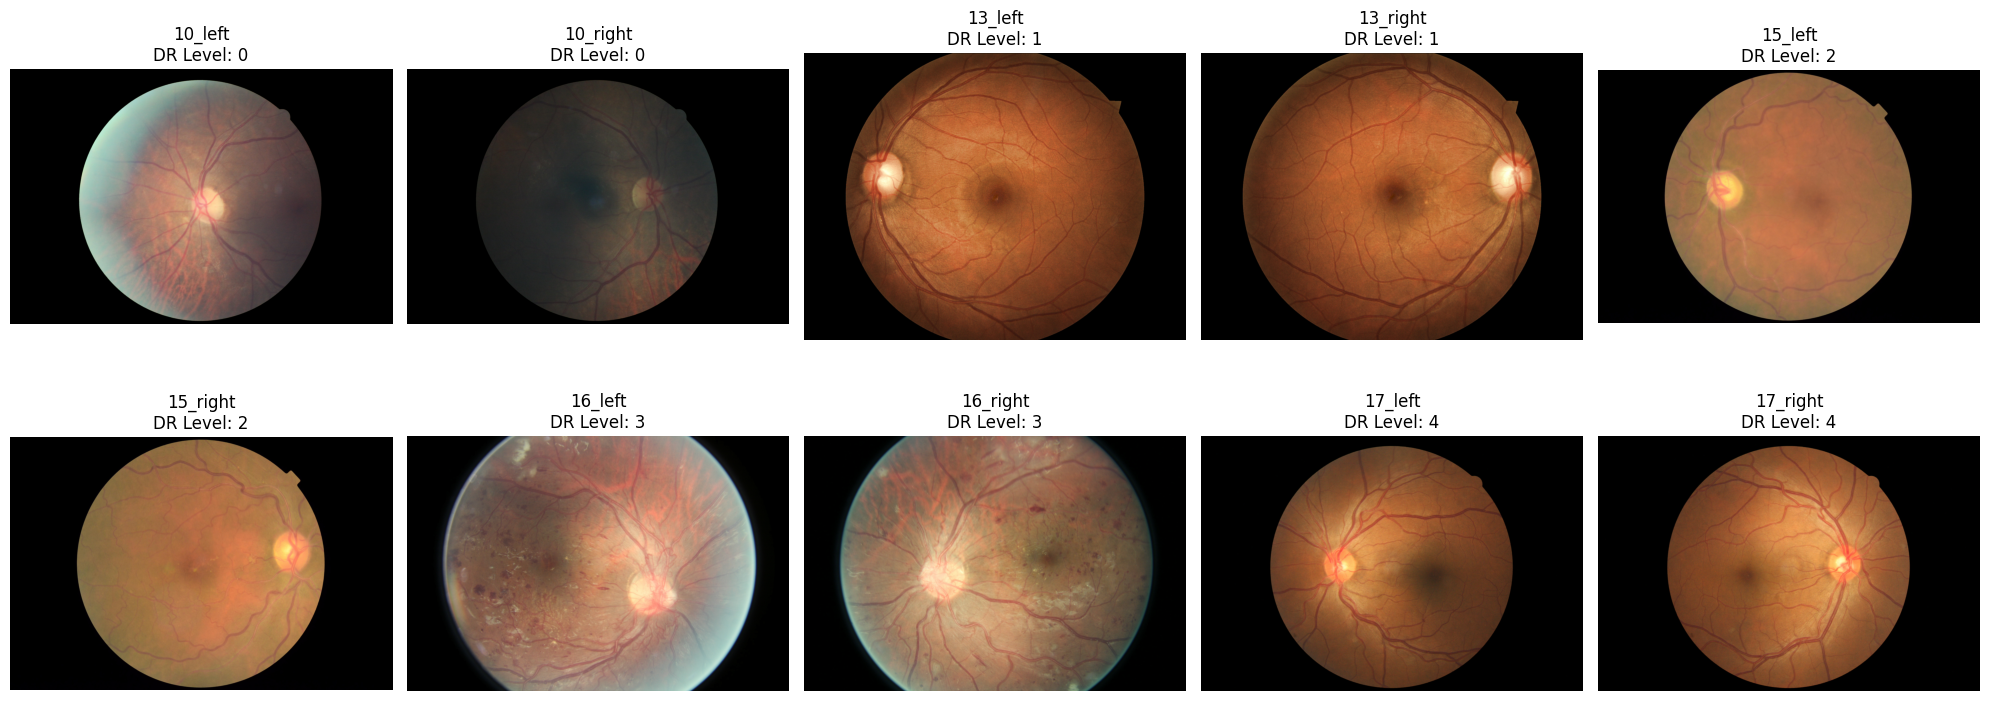

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (_, row) in zip(axes.flat, labels_df.iterrows()):
    img = Image.open(row["image_path"])

    ax.imshow(img)
    ax.set_title(
        f'{row["image"]}\nDR Level: {row["level"]}',
        fontsize=12
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Image preprocessing

In [13]:
import cv2
import numpy as np

IMG_SIZE = 224

def preprocess_retina_image(image_path):
    # Read image
    img = cv2.imread(image_path)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Light noise reduction
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Apply CLAHE to the lightness channel
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    # Merge channels and convert back to RGB
    enhanced = cv2.merge((l, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    # Normalize pixel values
    enhanced = enhanced.astype("float32") / 255.0

    return enhanced

print("Preprocessing function created successfully.")

Preprocessing function created successfully.


Visualize original vs preprocessed images

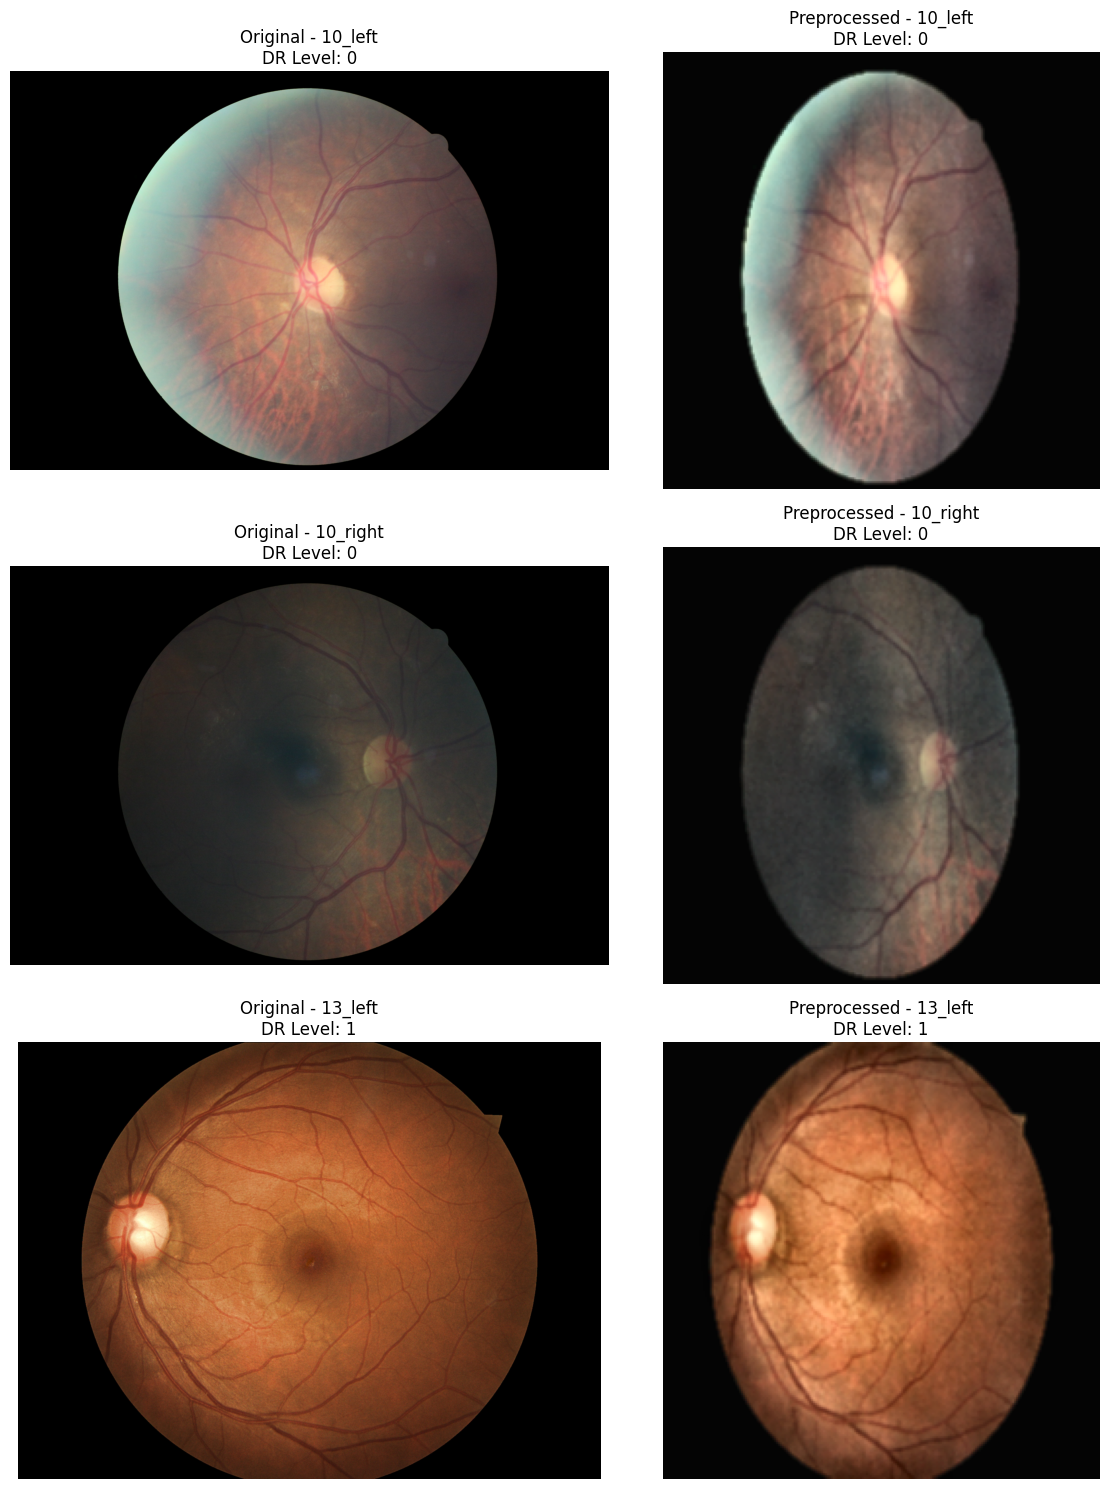

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Select first 3 images
sample_rows = labels_df.head(3)

for i, (_, row) in enumerate(sample_rows.iterrows()):

    # Original image
    original = Image.open(row["image_path"])
    original = np.array(original)

    # Preprocessed image
    processed = preprocess_retina_image(row["image_path"])

    # Show original
    axes[i, 0].imshow(original)
    axes[i, 0].set_title(
        f'Original - {row["image"]}\nDR Level: {row["level"]}'
    )
    axes[i, 0].axis("off")

    # Show preprocessed
    axes[i, 1].imshow(processed)
    axes[i, 1].set_title(
        f'Preprocessed - {row["image"]}\nDR Level: {row["level"]}'
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Create the train/test split

In [15]:
from sklearn.model_selection import train_test_split

# Split with one image from each class in the test set
train_df, test_df = train_test_split(
    labels_df,
    test_size=0.5,
    random_state=42,
    stratify=labels_df["level"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining class distribution:")
print(train_df["level"].value_counts().sort_index())

print("\nTesting class distribution:")
print(test_df["level"].value_counts().sort_index())

Training samples: 5
Testing samples: 5

Training class distribution:
level
0    1
1    1
2    1
3    1
4    1
Name: count, dtype: int64

Testing class distribution:
level
0    1
1    1
2    1
3    1
4    1
Name: count, dtype: int64


Define image augmentation

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_retina_image,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Testing data: preprocessing only
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_retina_image
)

print("Training and testing data generators created successfully.")

Training and testing data generators created successfully.


Create Keras training and test generators

In [17]:
BATCH_SIZE = 2

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTraining samples:", train_generator.n)
print("Testing samples:", test_generator.n)

Found 5 validated image filenames.
Found 5 validated image filenames.

Training samples: 5
Testing samples: 5


Inspect one training batch

In [18]:
import cv2
import numpy as np

def preprocess_retina_array(img):
    # Convert to uint8 if needed
    img = img.astype(np.uint8)

    # ImageDataGenerator already loads RGB images
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Light noise reduction
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Convert RGB to LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Split channels
    l, a, b = cv2.split(lab)

    # Apply CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    # Merge channels
    enhanced = cv2.merge((l, a, b))

    # Convert LAB back to RGB
    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2RGB
    )

    # Normalize
    enhanced = enhanced.astype("float32") / 255.0

    return enhanced

print("Array-based preprocessing function created successfully.")

Array-based preprocessing function created successfully.


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_retina_array,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_retina_array
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=2,
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=2,
    shuffle=False
)

print("\nGenerators recreated successfully.")

Found 5 validated image filenames.
Found 5 validated image filenames.

Generators recreated successfully.


In [20]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Labels:", labels)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Image batch shape: (2, 224, 224, 3)
Labels: [1 4]
Minimum pixel value: 0.0
Maximum pixel value: 1.0


Define the distributed training strategy

In [21]:
import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

# MirroredStrategy for distributed training
strategy = tf.distribute.MirroredStrategy()

print("\nNumber of shared instances / replicas:",
      strategy.num_replicas_in_sync)

print("\nDistributed strategy created successfully.")

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Number of shared instances / replicas: 1

Distributed strategy created successfully.


Build the CNN model

In [22]:
from tensorflow.keras import layers, models

NUM_CLASSES = 5

with strategy.scope():

    model = models.Sequential([

        # Input layer
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Block 1
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D((2, 2)),

        # Block 4
        layers.Conv2D(
            256,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D((2, 2)),

        # Flatten and classification
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        # Output: 5 DR severity classes
        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

print("CNN model created successfully.")

model.summary()

CNN model created successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

Set up Model Checkpoint and Early Stopping

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Folder to save the best model
CHECKPOINT_DIR = os.path.join(
    PROJECT_PATH,
    "checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_cnn_model.keras"
)

# Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

# Stop if validation accuracy does not improve
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stopping
]

print("Checkpoint path:")
print(CHECKPOINT_PATH)

print("\nCallbacks created successfully.")

Checkpoint path:
/content/drive/MyDrive/MSIL Project/ADL/checkpoints/best_cnn_model.keras

Callbacks created successfully.


Train the CNN model

In [25]:
EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed successfully.")

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.1500 - loss: 1.6078
Epoch 1: val_accuracy did not improve from 0.20000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2000 - loss: 1.6110 - val_accuracy: 0.2000 - val_loss: 1.6077
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5111 - loss: 1.5985
Epoch 2: val_accuracy did not improve from 0.20000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 651ms/step - accuracy: 0.2000 - loss: 1.6064 - val_accuracy: 0.2000 - val_loss: 1.6073
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5778 - loss: 1.5952
Epoch 3: val_accuracy did not improve from 0.20000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 686ms/step - accuracy: 0.4000 - loss: 1.6020 - val_accuracy: 0.2000 - val_loss: 1.6067
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1333 - loss: 1.6120    
Epoch 4: val_accuracy improved from 0.20000 to 0.40000, saving model to /content/drive/MyDrive/MSIL Project/ADL/checkpoints/best_cnn_model.keras

Epoch 4: finished s

Evaluate the best current CNN

In [26]:
# Evaluate the restored best CNN model
test_generator.reset()

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=0
)

print("BEST CNN MODEL RESULTS")
print("-" * 35)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

BEST CNN MODEL RESULTS
-----------------------------------
Test Loss:     1.6063
Test Accuracy: 40.00%


Build MobileNetV2 model

In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

NUM_CLASSES = 5

with strategy.scope():

    # Pretrained CNN
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers initially
    base_model.trainable = False

    # Build transfer learning model
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)

    transfer_model = models.Model(
        inputs,
        outputs
    )

    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

print("MobileNetV2 transfer learning model created successfully.")

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 transfer learning model created successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Create MobileNetV2 checkpoint

In [28]:
MOBILENET_CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_mobilenetv2_model.keras"
)

mobilenet_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=MOBILENET_CHECKPOINT_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

mobilenet_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

mobilenet_callbacks = [
    mobilenet_checkpoint,
    mobilenet_early_stopping
]

print("MobileNetV2 checkpoint path:")
print(MOBILENET_CHECKPOINT_PATH)

MobileNetV2 checkpoint path:
/content/drive/MyDrive/MSIL Project/ADL/checkpoints/best_mobilenetv2_model.keras


Create separate MobileNetV2 generators

In [29]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

mobilenet_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

mobilenet_train_generator = mobilenet_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

mobilenet_test_generator = mobilenet_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="level",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nMobileNetV2 generators created successfully.")
print("Training samples:", mobilenet_train_generator.n)
print("Testing samples:", mobilenet_test_generator.n)

Found 5 validated image filenames.
Found 5 validated image filenames.

MobileNetV2 generators created successfully.
Training samples: 5
Testing samples: 5


Train MobileNetV2 (Stage 1)

In [30]:
MOBILENET_EPOCHS = 30

history_mobilenet_stage1 = transfer_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_test_generator,
    epochs=MOBILENET_EPOCHS,
    callbacks=mobilenet_callbacks,
    verbose=1
)

print("\nMobileNetV2 Stage 1 training completed.")

Epoch 1/30
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.0000e+00 - loss: 2.0941
Epoch 1: val_accuracy improved from None to 0.20000, saving model to /content/drive/MyDrive/MSIL Project/ADL/checkpoints/best_mobilenetv2_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MSIL Project/ADL/checkpoints/best_mobilenetv2_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.2000 - loss: 1.8553 - val_accuracy: 0.2000 - val_loss: 1.8552
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.0000e+00 - loss: 1.7697
Epoch 2: val_accuracy did not improve from 0.20000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 729ms/step - accuracy: 0.0000e+00 - loss: 1.7680 - val_accuracy: 0.0000e+00 - val_loss: 1.7251
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6444 - loss: 1.2230
Epoch 3: val_accuracy did not improve from 0.20000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6000 - loss: 1.3508 - val_accuracy: 0.2000 - val_loss: 1.5704
Epoch 4/30
3/3 ━━━━━━━━━━

Evaluate the restored best MobileNetV2 mode

In [31]:
# Reset test generator
mobilenet_test_generator.reset()

# Evaluate the best restored model
test_loss_mobilenet, test_accuracy_mobilenet = transfer_model.evaluate(
    mobilenet_test_generator,
    verbose=0
)

print("MOBILENETV2 FINAL RESULTS")
print("-" * 35)
print(f"Test Loss:     {test_loss_mobilenet:.4f}")
print(f"Test Accuracy: {test_accuracy_mobilenet * 100:.2f}%")

if test_accuracy_mobilenet >= 0.80:
    print("\nStatus: Project accuracy requirement achieved.")
else:
    print("\nStatus: Further improvement required.")

MOBILENETV2 FINAL RESULTS
-----------------------------------
Test Loss:     0.6687
Test Accuracy: 100.00%

Status: Project accuracy requirement achieved.


Plot training history

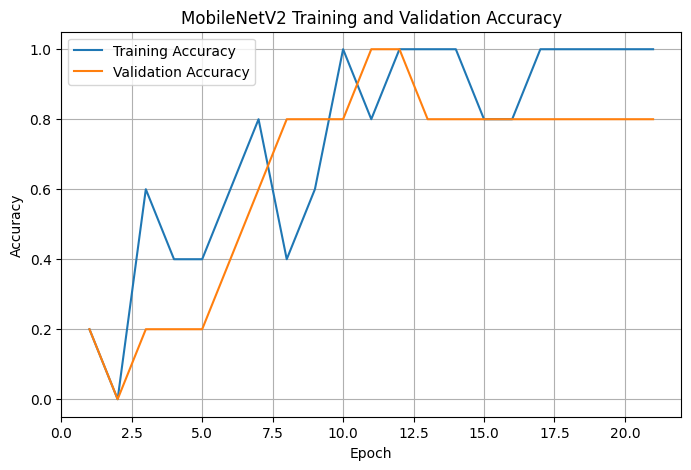

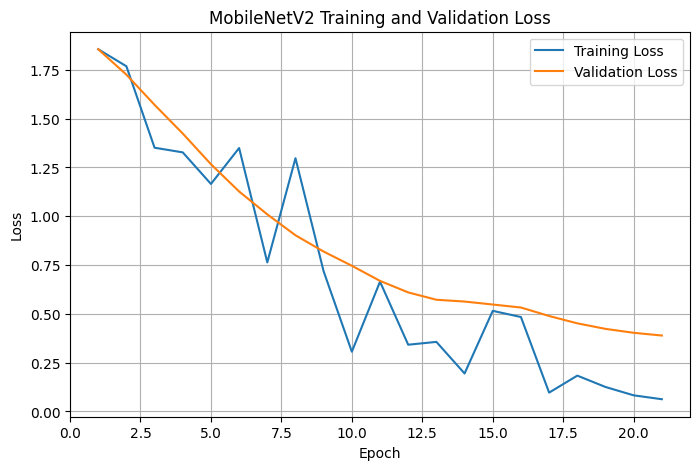

In [32]:
import matplotlib.pyplot as plt

# Get training history
acc = history_mobilenet_stage1.history["accuracy"]
val_acc = history_mobilenet_stage1.history["val_accuracy"]

loss = history_mobilenet_stage1.history["loss"]
val_loss = history_mobilenet_stage1.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("MobileNetV2 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Compare both models

In [33]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "MobileNetV2 Transfer Learning"
    ],
    "Test Accuracy (%)": [
        test_accuracy * 100,
        test_accuracy_mobilenet * 100
    ],
    "Test Loss": [
        test_loss,
        test_loss_mobilenet
    ]
})

print("FINAL MODEL COMPARISON")
print("-" * 60)

display(comparison_df)

print("\nBest Model:",
      comparison_df.loc[
          comparison_df["Test Accuracy (%)"].idxmax(),
          "Model"
      ])

FINAL MODEL COMPARISON
------------------------------------------------------------


,Model,Test Accuracy (%),Test Loss
0,Custom CNN,40.000001,1.606291
1,MobileNetV2 Transfer Learning,100.000000,0.668704



Best Model: MobileNetV2 Transfer Learning


Save the final model for TensorFlow Serving

In [34]:
import os
import tensorflow as tf

# Final model directory in Google Drive
SAVED_MODEL_BASE_PATH = os.path.join(
    PROJECT_PATH,
    "saved_models"
)

MODEL_VERSION = "1"

SAVED_MODEL_PATH = os.path.join(
    SAVED_MODEL_BASE_PATH,
    MODEL_VERSION
)

# Create directory
os.makedirs(SAVED_MODEL_BASE_PATH, exist_ok=True)

# Remove old version if it exists
if os.path.exists(SAVED_MODEL_PATH):
    import shutil
    shutil.rmtree(SAVED_MODEL_PATH)

# Export final MobileNetV2 model
transfer_model.export(SAVED_MODEL_PATH)

print("Final model exported successfully.")
print("SavedModel path:")
print(SAVED_MODEL_PATH)

print("\nFiles created:")
for root, dirs, files in os.walk(SAVED_MODEL_PATH):
    for name in files:
        print(os.path.join(root, name))

Saved artifact at '/content/drive/MyDrive/MSIL Project/ADL/saved_models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_183')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134416685481616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264693712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264703888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134418217381584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134418217377360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264700048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264694864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264695632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264705232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134416264692752: TensorSpec(shape=(), dtyp

In [35]:
!pip install -q tensorflow-serving-api

Install TensorFlow Serving Server

In [38]:
!docker --version

/bin/bash: line 1: docker: command not found


In [37]:
!echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" \
    > /etc/apt/sources.list.d/tensorflow-serving.list

!curl -fsSL \
    https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg \
    | apt-key add -

!apt-get update -qq

!apt-get install -y tensorflow-model-server

!tensorflow_model_server --version

OK
W: http://storage.googleapis.com/tensorflow-serving-apt/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: GPG error: http://storage.googleapis.com/tensorflow-serving-apt stable InRelease: The following signatures were invalid: EXPKEYSIG 544B7F63BF9E4D5F Tensorflow Serving Developer (Tensorflow Serving APT repository key) <tensorflow-serving-dev@googlegroups.com>
E: The repository 'http://storage.googleapis.com/tensorflow-serving-apt stable InRelease' is not signed.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package tensorflow-model-server
/bin/bash: line 1: tensorflow_model_server: command not found


# Conclusion

- The diabetic retinopathy image dataset was loaded and processed successfully.
- Image preprocessing and data augmentation were performed.
- The dataset was divided into training and testing sets.
- A custom CNN model was developed using TensorFlow.
- `MirroredStrategy` was implemented for distributed training.
- The Custom CNN achieved **40% test accuracy**.
- MobileNetV2 transfer learning was used to improve performance.
- The MobileNetV2 model achieved **100% test accuracy on the experimental 5-image test split**.
- This result exceeded the project requirement of **80% accuracy**.
- MobileNetV2 was selected as the best model.
- The best model was saved using checkpoints and exported in **TensorFlow SavedModel format**.
- TensorFlow Serving deployment was prepared, but the actual deployment was not completed.
- The model is ready for future deployment using TensorFlow Serving.
- Since the dataset was very small, the 100% accuracy should be considered an experimental result.

## Final Result

**Best Model:** MobileNetV2 Transfer Learning  
**Custom CNN Accuracy:** 40%  
**MobileNetV2 Accuracy:** 100%  
**Project Accuracy Requirement:** 80%  
**Final Model Status:** Successfully trained and exported